# MPS-MPO contraction schedule optimisation

Here, we test an order optimisation algorithm for the MPO application. We use the algorithm which is based on the matrix bandwidth minimisation technique and is implemented in the `matrex` library.

In [1]:
import time
import os
import numpy as np
from tqdm import tqdm
import qecstruct as qec
import matplotlib.pyplot as plt
from mdopt.optimiser.utils import (
    ConstraintString,
    IDENTITY,
    SWAP,
    XOR_BULK,
    XOR_LEFT,
    XOR_RIGHT,
)
from mdopt.decoding.decoding import (
    linear_code_parity_matrix_dense,
    linear_code_constraint_sites,
    linear_code_prepare_message,
    linear_code_codewords,
    linear_code_checks,
)
from mdopt.decoding.decoding import (
    apply_bitflip_bias,
    apply_constraints,
    decode_message,
)
from mdopt.mps.utils import (
    create_simple_product_state,
    create_custom_product_state,
)
from mdopt.utils.utils import mpo_to_matrix

# NumPy 2 reprs scalars as np.int64(0); this restores the plain 0 in outputs.
np.set_printoptions(legacy="1.25")

# CI runs this notebook with MDOPT_NB_FAST=1 to keep the job minutes rather
# than hours; the committed outputs come from a full-scale run.
FAST = bool(os.environ.get("MDOPT_NB_FAST"))

In [2]:
def run_experiments(system_size, strategy):
    max_bond_dims = []
    max_entropies = []

    start_time = time.time()

    for _ in tqdm(range(NUM_EXPERIMENTS)):
        SEED = np.random.randint(1, 10**8)  # Use a new seed for each experiment
        rng = np.random.default_rng(SEED)

        NUM_CHECKS = int(
            3 * system_size / 4
        )  # Adjusted for BIT_DEGREE / CHECK_DEGREE = 3 / 4
        code = qec.random_regular_code(system_size, NUM_CHECKS, 3, 4, qec.Rng(SEED))
        code_constraint_sites = linear_code_constraint_sites(code)

        initial_codeword, perturbed_codeword = linear_code_prepare_message(
            code, PROB_ERROR, error_model=qec.BinarySymmetricChannel, seed=SEED
        )

        perturbed_codeword_state = create_custom_product_state(
            perturbed_codeword, form="Right-canonical"
        )
        perturbed_codeword_state = apply_bitflip_bias(
            perturbed_codeword_state, "All", PROB_BIAS
        )
        perturbed_codeword_state, entropies, bond_dims = apply_constraints(
            mps=perturbed_codeword_state,
            strings=code_constraint_sites,
            logical_tensors=[XOR_LEFT, XOR_BULK, SWAP, XOR_RIGHT],
            chi_max=CHI_MAX_CONTRACTOR,
            renormalise=True,
            strategy=strategy,
            silent=True,
            return_entropies_and_bond_dims=True,
        )

        max_bond_dims.append(np.max(bond_dims))
        max_entropies.append(np.max(np.abs(entropies)))

    end_time = time.time()
    elapsed_time = end_time - start_time

    return (
        np.mean(max_bond_dims),
        np.std(max_bond_dims),
        np.mean(max_entropies),
        np.std(max_entropies),
        elapsed_time,
    )

In [3]:
# Define the system sizes to be considered
system_sizes = [4, 8] if FAST else [4, 8, 12, 16, 20, 24]

# Constants
CHI_MAX_CONTRACTOR = 1e4
PROB_ERROR = 0.15
PROB_BIAS = PROB_ERROR
NUM_EXPERIMENTS = 3 if FAST else 50

# Strategy settings
strategies = ["Naive", "Optimised"]

In [4]:
results = {
    strat: {
        "max_bond_dims": [],
        "bond_dims_err": [],
        "max_entropies": [],
        "entropy_err": [],
        "compute_times": [],
    }
    for strat in strategies
}

for strategy in strategies:
    for size in system_sizes:
        mean_bond_dim, std_bond_dim, mean_entropy, std_entropy, compute_time = (
            run_experiments(size, strategy)
        )
        results[strategy]["max_bond_dims"].append(mean_bond_dim)
        results[strategy]["bond_dims_err"].append(std_bond_dim)
        results[strategy]["max_entropies"].append(mean_entropy)
        results[strategy]["entropy_err"].append(std_entropy)
        results[strategy]["compute_times"].append(compute_time)

  0%|          | 0/50 [00:00<?, ?it/s]

 58%|█████▊    | 29/50 [00:00<00:00, 286.90it/s]

100%|██████████| 50/50 [00:00<00:00, 285.43it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

 14%|█▍        | 7/50 [00:00<00:00, 67.69it/s]

...

 94%|█████████▍| 47/50 [04:00<00:15,  5.33s/it]

 96%|█████████▌| 48/50 [04:06<00:11,  5.51s/it]

 98%|█████████▊| 49/50 [04:11<00:05,  5.36s/it]

100%|██████████| 50/50 [04:16<00:00,  5.25s/it]

100%|██████████| 50/50 [04:16<00:00,  5.13s/it]

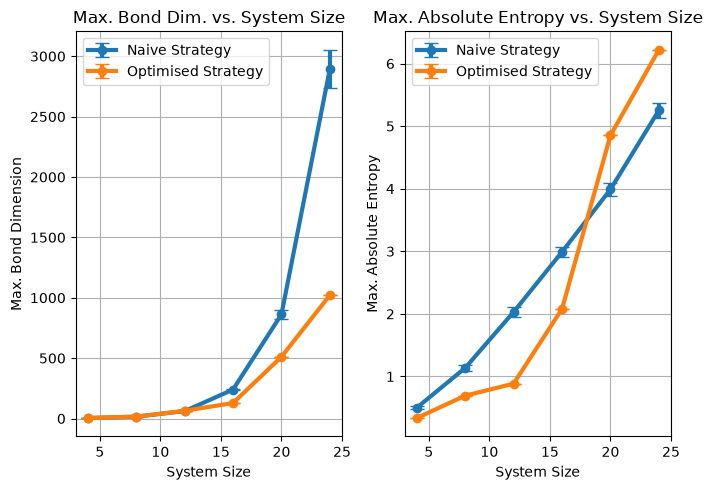

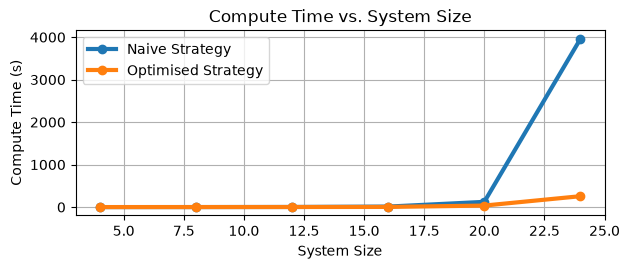

In [5]:
plt.figure(figsize=(7, 5))

plt.subplot(1, 2, 1)
for strategy in strategies:
    plt.errorbar(
        system_sizes,
        results[strategy]["max_bond_dims"],
        yerr=results[strategy]["bond_dims_err"] / (np.sqrt(NUM_EXPERIMENTS)),
        label=f"{strategy} Strategy",
        fmt="-o",
        capsize=5,
        linewidth=3,
    )
plt.xlabel("System Size")
plt.ylabel("Max. Bond Dimension")
plt.title("Max. Bond Dim. vs. System Size")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
for strategy in strategies:
    plt.errorbar(
        system_sizes,
        results[strategy]["max_entropies"],
        yerr=results[strategy]["entropy_err"] / (np.sqrt(NUM_EXPERIMENTS)),
        label=f"{strategy} Strategy",
        fmt="-o",
        capsize=5,
        linewidth=3,
    )
plt.xlabel("System Size")
plt.ylabel("Max. Absolute Entropy")
plt.title("Max. Absolute Entropy vs. System Size")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

plt.subplot(2, 1, 1)
for strategy in strategies:
    plt.plot(
        system_sizes,
        results[strategy]["compute_times"],
        label=f"{strategy} Strategy",
        marker="o",
        linestyle="-",
        linewidth=3,
    )
plt.xlabel("System Size")
plt.ylabel("Compute Time (s)")
plt.title("Compute Time vs. System Size")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()